In [ ]:
# 1. Imports & Configuration
import pandas as pd
import numpy as np
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

# 2. Load & Prepare Data
data_path = "data/raw/Indian_Stocks_OHLCV"  # folder containing extracted CSVs
stocks = []

for file in os.listdir(data_path):
    if file.endswith('.csv'):
        df = pd.read_csv(os.path.join(data_path, file))
        df['Stock'] = file.replace('.csv', '')
        df['Date'] = pd.to_datetime(df['Date'], dayfirst=True, errors='coerce')
        df = df.dropna(subset=['Date'])
        stocks.append(df)


data = pd.concat(stocks).sort_values(['Stock', 'Date']).reset_index(drop=True)

# 3. Feature Engineering (Momentum-Based)
def add_features(df):
    df = df.copy()
    df['Return_5'] = df['Close'].pct_change(5)
    df['Return_20'] = df['Close'].pct_change(20)
    df['Return_60'] = df['Close'].pct_change(60)

    df['Vol_20'] = df['Close'].pct_change().rolling(20).std()
    df['SMA_20'] = df['Close'].rolling(20).mean()
    df['SMA_50'] = df['Close'].rolling(50).mean()
    df['SMA_Ratio'] = df['Close'] / df['SMA_20']

    delta = df['Close'].diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs = avg_gain / avg_loss
    df['RSI'] = 100 - (100 / (1 + rs))

    df['Forward_Return_5'] = df['Close'].pct_change(5).shift(-5)
    df['Target'] = (df['Forward_Return_5'] > 0).astype(int)
    return df


data = data.groupby('Stock', group_keys=False).apply(add_features)
data.dropna(inplace=True)

# 4. Train-Test Split (STRICT)
train = data[data['Date'] < '2023-01-01']
test = data[data['Date'] >= '2023-01-01']

features = ['Return_5', 'Return_20', 'Return_60', 'Vol_20', 'SMA_Ratio', 'RSI']

# 5. Model Training (Per Stock)
models = {}
scalers = {}

for stock in train['Stock'].unique():
    df_train = train[train['Stock'] == stock]

    X = df_train[features]
    y = df_train['Target']

    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    model = RandomForestClassifier(
        n_estimators=200,
        max_depth=5,
        random_state=42
    )
    model.fit(X_scaled, y)

    models[stock] = model
    scalers[stock] = scaler

# 6. Prediction on Test Data
predictions = []

for stock in test['Stock'].unique():
    df_test = test[test['Stock'] == stock]

    X_test = df_test[features]
    X_test_scaled = scalers[stock].transform(X_test)

    probs = models[stock].predict_proba(X_test_scaled)[:, 1]

    temp = df_test[['Date', 'Stock']].copy()
    temp['Predicted_Prob'] = probs
    temp['Signal'] = (probs > 0.6).astype(int)
    predictions.append(temp)

pred_df = pd.concat(predictions)
pred_df.to_csv('outputs/predictions.csv', index=False)

# 7. Simple Performance Check (Accuracy Only – Sanity)
accs = []
for stock in test['Stock'].unique():
    df_test = test[test['Stock'] == stock]
    y_true = df_test['Target']
    y_pred = (pred_df[pred_df['Stock'] == stock]['Predicted_Prob'] > 0.6).astype(int)
    accs.append(accuracy_score(y_true, y_pred))

print("Average Test Accuracy:", np.mean(accs))

# SAVE PROCESSED DATA FOR NEXT STEPS
os.makedirs("data", exist_ok=True)

data.to_csv("data/processed_data.csv", index=False)

print("✅ processed_data.csv saved successfully")



C:\Users\Varun Kaushik\AppData\Local\Temp\ipykernel_21660\2256261028.py:61: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  data = data.groupby('Stock', group_keys=False).apply(add_features)


Average Test Accuracy: 0.4763586956521739
✅ processed_data.csv saved successfully


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load predictions from Step 1
pred_df = pd.read_csv("outputs/predictions.csv", parse_dates=['Date'])

# Use price data from Step 1
price_data = data[['Date', 'Stock', 'Close']].copy()

# Convert daily data to weekly (Friday)
pred_df['Week'] = pred_df['Date'].dt.to_period('W').apply(lambda r: r.start_time)
price_data['Week'] = price_data['Date'].dt.to_period('W').apply(lambda r: r.start_time)

weekly_pred = pred_df.groupby(['Week', 'Stock']).last().reset_index()
weekly_price = price_data.groupby(['Week', 'Stock']).last().reset_index()


In [ ]:
TOP_K = 3  # select top 3 stocks weekly

weekly_pred = weekly_pred.sort_values(['Week', 'Predicted_Prob'], ascending=[True, False])
weekly_pred['Rank'] = weekly_pred.groupby('Week')['Predicted_Prob'].rank(ascending=False)
weekly_pred['Selected'] = (weekly_pred['Rank'] <= TOP_K).astype(int)


In [19]:
weekly_pred['Weight'] = weekly_pred.groupby('Week')['Selected'].transform(
    lambda x: x / x.sum() if x.sum() > 0 else 0
)

weights = weekly_pred[['Week', 'Stock', 'Weight']]
weights.to_csv("outputs/weekly_weights.csv", index=False)


In [20]:
weekly_price['Next_Close'] = weekly_price.groupby('Stock')['Close'].shift(-1)
weekly_price['Weekly_Return'] = (weekly_price['Next_Close'] / weekly_price['Close']) - 1

portfolio = weekly_pred.merge(
    weekly_price[['Week', 'Stock', 'Weekly_Return']],
    on=['Week', 'Stock'],
    how='left'
)

portfolio['Weighted_Return'] = portfolio['Weight'] * portfolio['Weekly_Return']

portfolio_returns = portfolio.groupby('Week')['Weighted_Return'].sum().reset_index()
portfolio_returns['Cumulative_Return'] = (1 + portfolio_returns['Weighted_Return']).cumprod()


In [21]:
def sharpe_ratio(returns):
    return np.sqrt(52) * returns.mean() / returns.std()

CAGR = portfolio_returns['Cumulative_Return'].iloc[-1] ** (52 / len(portfolio_returns)) - 1
Sharpe = sharpe_ratio(portfolio_returns['Weighted_Return'])

rolling_max = portfolio_returns['Cumulative_Return'].cummax()
drawdown = portfolio_returns['Cumulative_Return'] / rolling_max - 1
Max_Drawdown = drawdown.min()

print(f"CAGR: {CAGR*100:.2f}%")
print(f"Sharpe Ratio: {Sharpe:.2f}")
print(f"Max Drawdown: {Max_Drawdown*100:.2f}%")


CAGR: 8.63%
Sharpe Ratio: 0.62
Max Drawdown: -18.28%


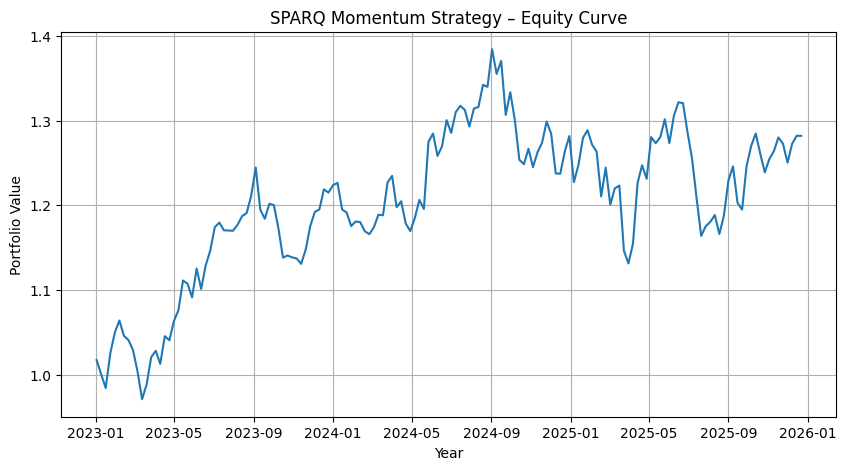

In [22]:
plt.figure(figsize=(10, 5))
plt.plot(portfolio_returns['Week'], portfolio_returns['Cumulative_Return'])
plt.title("SPARQ Momentum Strategy – Equity Curve")
plt.xlabel("Year")
plt.ylabel("Portfolio Value")
plt.grid(True)
plt.show()
